In [ ]:
import joblib             as jlb
import matplotlib.pyplot  as plt
import numpy              as np
import pandas             as pd
import seaborn            as sbn
import warnings
warnings.filterwarnings('ignore') # tắt những cảnh báo

from collections           import Counter
from sklearn.cluster       import DBSCAN
from sklearn.preprocessing import LabelEncoder, StandardScaler
from customer_clustering.Processing_data.Customer_dataset import data_scaled 
processed_data = data_scaled.copy()

Tiền xử lý dữ liệu

In [4]:

print(processed_data.head())
print(processed_data.shape)

    balance  purchases  cash_advance  credit_limit  payments  minimum_payments
0 -0.744625  -0.429184     -0.468655     -0.962575 -0.543942         -0.305508
1  0.764152  -0.473208      2.568556      0.677204  0.796852          0.087689
2  0.426602  -0.116413     -0.468655      0.813852 -0.399503         -0.099906
3 -0.373910  -0.465825     -0.468655     -0.907916 -0.380165         -0.261131
4  0.099551   0.142062     -0.468655     -0.743938 -0.132119          0.650363
(8636, 6)


In [5]:
## Quan sát sơ bộ dữ liệu
print('Shape:', processed_data.shape)
print()
print(processed_data.dtypes)

Shape: (8636, 6)

balance             float64
purchases           float64
cash_advance        float64
credit_limit        float64
payments            float64
minimum_payments    float64
dtype: object


In [6]:
##------------------------------------------------------------------------------
## Xây dựng mô hình DBSCAN
##------------------------------------------------------------------------------
## eps        : bán kính lân cận (neighborhood radius)
## min_samples: số điểm tối thiểu trong lân cận để tạo thành core point
##
## Nhãn cluster = -1 → điểm NHIỄU (noise/outlier), không thuộc cụm nào
##------------------------------------------------------------------------------
model = DBSCAN(eps=1.5, min_samples=10)
model.fit(processed_data)  # xây dựng mô hình

,eps,1.5
,min_samples,10
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [7]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(model, '../customer_clustering/Output/DBSCAN.mdl')

['../customer_clustering/Output/DBSCAN.mdl']

In [8]:
## Khai thác mô hình đã được xây dựng
model = jlb.load('../customer_clustering/Output/DBSCAN.mdl')

In [9]:
## Kết quả gom cụm khách hàng
processed_data['cluster'] = model.labels_
print(processed_data[['balance',
    'purchases',
    'cash_advance',
    'credit_limit',
    'payments',
    'minimum_payments']].head(10))

n_clusters = len(set(model.labels_)) - (1 if -1 in model.labels_ else 0)
n_noise    = list(model.labels_).count(-1)

print(f'\nSố clusters tìm được  : {n_clusters}')
print(f'Số điểm nhiễu (noise): {n_noise}')
print('\nKích thước các clusters (bao gồm noise = -1):', Counter(model.labels_))

    balance  purchases  cash_advance  credit_limit  payments  minimum_payments
0 -0.744625  -0.429184     -0.468655     -0.962575 -0.543942         -0.305508
1  0.764152  -0.473208      2.568556      0.677204  0.796852          0.087689
2  0.426602  -0.116413     -0.468655      0.813852 -0.399503         -0.099906
3 -0.373910  -0.465825     -0.468655     -0.907916 -0.380165         -0.261131
4  0.099551   0.142062     -0.468655     -0.743938 -0.132119          0.650363
5 -0.464799   2.799089     -0.468655      2.453632  1.570584         -0.280826
6  0.106148  -0.271914     -0.468655     -0.607290 -0.379914         -0.140055
7 -0.279796  -0.075655     -0.468655      0.677204 -0.376747         -0.232817
8 -0.691498   0.118213     -0.468655      1.770390 -0.212984         -0.322034
9 -0.147033  -0.048599     -0.468655     -0.907916 -0.240984          0.551499

Số clusters tìm được  : 1
Số điểm nhiễu (noise): 192

Kích thước các clusters (bao gồm noise = -1): Counter({np.int64(0): 8444, np

Biểu diễn trực quan

In [10]:
## Lấy 2 thuộc tính số để vẽ: Income Level và Age
data2d = processed_data[['purchases', 'balance']].copy()

In [11]:

scaler      = StandardScaler()
data2d_scaled = scaler.fit_transform(data2d)

In [12]:
model2d = DBSCAN(eps=0.2, min_samples=10)
model2d.fit(data2d)

data2d['cluster'] = model2d.labels_
print(data2d.head(10))

n_clusters = len(set(model2d.labels_)) - (1 if -1 in model2d.labels_ else 0)
n_noise    = list(model2d.labels_).count(-1)
print(f'\nSố clusters tìm được  : {n_clusters}')
print(f'Số điểm nhiễu (noise): {n_noise}')
print('\nClusters lớn nhất:', Counter(model2d.labels_).most_common(1))

   purchases   balance  cluster
0  -0.429184 -0.744625        0
1  -0.473208  0.764152        0
2  -0.116413  0.426602        0
3  -0.465825 -0.373910        0
4   0.142062  0.099551        0
5   2.799089 -0.464799        0
6  -0.271914  0.106148        0
7  -0.075655 -0.279796        0
8   0.118213 -0.691498        0
9  -0.048599 -0.147033        0

Số clusters tìm được  : 3
Số điểm nhiễu (noise): 331

Clusters lớn nhất: [(np.int64(0), 8280)]


In [13]:
for eps in [0.2, 0.3, 0.5, 0.8, 1.0]:
    m          = DBSCAN(eps = eps, min_samples = 10).fit(data2d)
    n_clusters = len(set(m.labels_)) - (1 if -1 in m.labels_ else 0)
    n_noise    = list(m.labels_).count(-1)
    print(f'eps={eps} → clusters: {n_clusters}, noise: {n_noise}')

eps=0.2 → clusters: 2, noise: 339
eps=0.3 → clusters: 6, noise: 243
eps=0.5 → clusters: 5, noise: 116
eps=0.8 → clusters: 3, noise: 59
eps=1.0 → clusters: 3, noise: 51


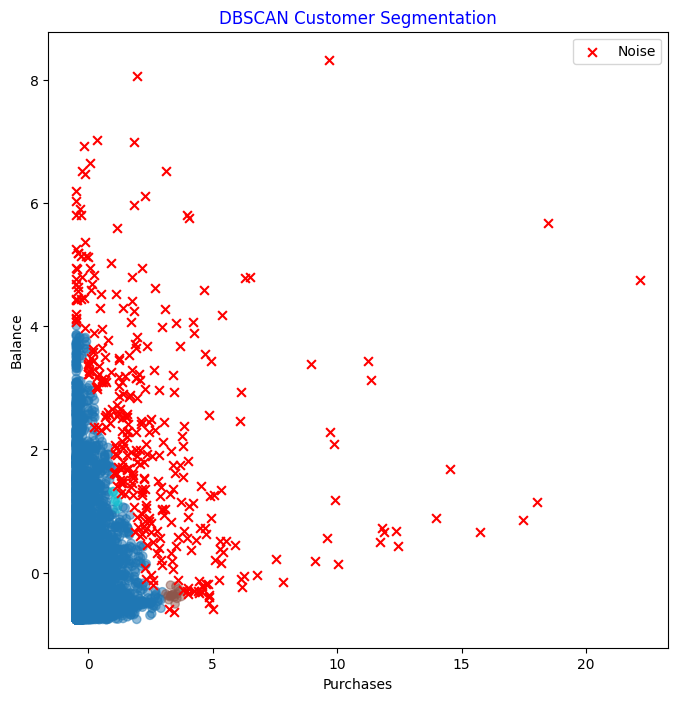

In [14]:
noise    = data2d[data2d.cluster == -1]
clusters = data2d[data2d.cluster != -1]

plt.figure(figsize=(8, 8))
plt.scatter(clusters.purchases, clusters['balance'], c=clusters.cluster, alpha=0.5, cmap='tab10')
plt.scatter(noise.purchases, noise['balance'], c='red', marker='x', s=40, label='Noise', zorder=5)
plt.xlabel('Purchases')
plt.ylabel('Balance')
plt.title('DBSCAN Customer Segmentation', color='blue')
plt.legend()
plt.show()